In [15]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [16]:
# filepath = '/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/background_templates/'
# folder = '2D_neutrons/'
# filename = '2D_neutrons_0.1'



with open('/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/background_templates/accidentals/toy_spectra/2827GeV_1.0.pkl', 'rb') as file:
    data = pickle.load(file)



print(data)

[{'SolarER': <multihist.Histdd object at 0x7fbbd260f310>, 'Pb214': <multihist.Histdd object at 0x7fbb2cac0b50>, 'Kr85': <multihist.Histdd object at 0x7fbb2b10a190>, 'Xe136': <multihist.Histdd object at 0x7fbb2b10bc50>, 'Xe124': <multihist.Histdd object at 0x7fbb2b142b10>, 'CEvNS_solar': <multihist.Histdd object at 0x7fbb2b142910>, 'CEvNS_other_LNGS': <multihist.Histdd object at 0x7fbb2b142110>, 'CEvNS_other_SURF': <multihist.Histdd object at 0x7fbb2b141f10>, 'neutrons_LNGS': <multihist.Histdd object at 0x7fbb2b142050>, 'accidentals': <multihist.Histdd object at 0x7fbb2b140910>}, {'WIMP': <multihist.Histdd object at 0x7fbc8cbcd190>}]


In [17]:
type(data)

list

In [18]:
print(data[0])
print(data[1])

print(data[0]['neutrons_LNGS'])

{'SolarER': <multihist.Histdd object at 0x7fbbd260f310>, 'Pb214': <multihist.Histdd object at 0x7fbb2cac0b50>, 'Kr85': <multihist.Histdd object at 0x7fbb2b10a190>, 'Xe136': <multihist.Histdd object at 0x7fbb2b10bc50>, 'Xe124': <multihist.Histdd object at 0x7fbb2b142b10>, 'CEvNS_solar': <multihist.Histdd object at 0x7fbb2b142910>, 'CEvNS_other_LNGS': <multihist.Histdd object at 0x7fbb2b142110>, 'CEvNS_other_SURF': <multihist.Histdd object at 0x7fbb2b141f10>, 'neutrons_LNGS': <multihist.Histdd object at 0x7fbb2b142050>, 'accidentals': <multihist.Histdd object at 0x7fbb2b140910>}
{'WIMP': <multihist.Histdd object at 0x7fbc8cbcd190>}


In [19]:
template_s1s2 = data[0]['accidentals']

In [20]:
template_norm = template_s1s2.n
template_s1s2 = template_s1s2 / template_s1s2.n
template_s1s2 = template_s1s2 / template_s1s2.bin_volumes()

In [21]:
template_norm

1.0000000000000007

In [22]:
template_s1s2

In [23]:
# # Selecting the background now

# background = 'accidentals'
background = 'WIMP'

In [24]:
# hist = data[0][background]
hist = data[1][background]

In [25]:
print(hist.__dict__.keys())

dict_keys(['axis_names', 'histogram', 'bin_edges'])


In [26]:
print(hist.axis_names)
print(hist.histogram.shape)
print([len(e) for e in hist.bin_edges])

['cS1', 'log10_cS2', 'rsq']
(100, 100, 50)
[101, 101, 51]


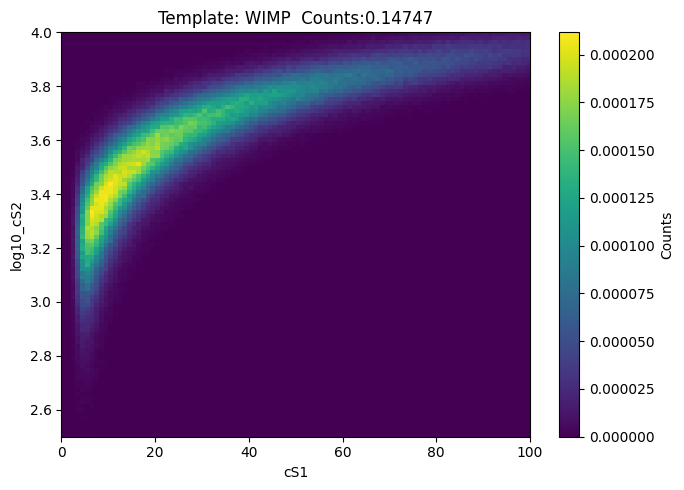

In [27]:
import numpy as np
arr = hist.histogram

if arr.ndim == 2:
    x_edges = hist.bin_edges[0]
    y_edges = hist.bin_edges[1]
    X, Y = np.meshgrid(x_edges, y_edges)
    plt.figure(figsize=(7,5))
    pcm = plt.pcolormesh(X, Y, arr.T, cmap='viridis')
    plt.colorbar(pcm, label='Counts')
    plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
    plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
    plt.title(f"Template: {background}  Counts:{hist.n :.5f}")
    plt.tight_layout()
    plt.show()

elif arr.ndim == 1:
    # keep existing 1D behaviour
    hist.plot()
    plt.title(f"Template: {background}  Counts:{hist.n :.5f}")
    plt.show()

else:
    # project all axes beyond the first two
    proj = arr.sum(axis=tuple(range(2, arr.ndim))) if arr.ndim > 2 else arr
    if len(hist.bin_edges) >= 2:
        x_edges = hist.bin_edges[0]
        y_edges = hist.bin_edges[1]
        X, Y = np.meshgrid(x_edges, y_edges)
        plt.figure(figsize=(7,5))
        pcm = plt.pcolormesh(X, Y, proj.T, cmap='viridis')
        plt.colorbar(pcm, label='Counts')
        plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
        plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
        plt.title(f"Template: {background}  Counts:{hist.n :.5f}")
        plt.tight_layout()
        plt.show()
    else:
        hist.plot()
        plt.title(f"Template: {background}  Counts:{hist.n :.5f}")
        plt.show()

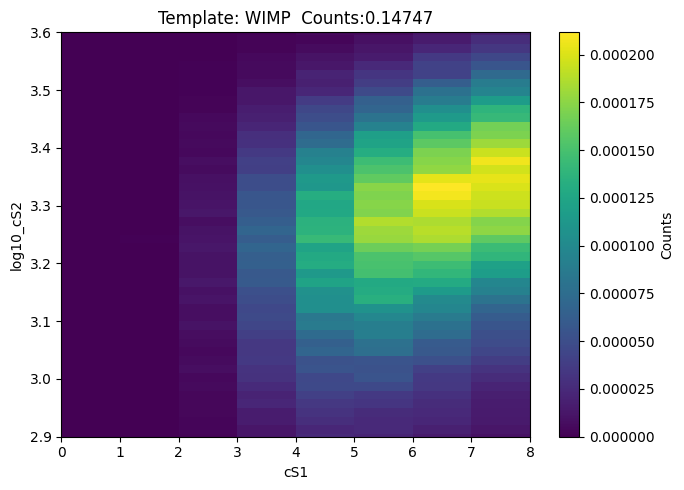

In [28]:
import numpy as np
arr = hist.histogram

if arr.ndim == 2:
    x_edges = hist.bin_edges[0]
    y_edges = hist.bin_edges[1]
    X, Y = np.meshgrid(x_edges, y_edges)
    plt.figure(figsize=(7,5))
    pcm = plt.pcolormesh(X, Y, arr.T, cmap='viridis')
    plt.colorbar(pcm, label='Counts')
    plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
    plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
    plt.title(f"Template: {background}  Counts:{hist.n :.5f}")
    plt.tight_layout()
    plt.show()

elif arr.ndim == 1:
    # keep existing 1D behaviour
    hist.plot()
    plt.title(f"Template: {background}  Counts:{hist.n :.5f}")
    plt.show()

else:
    # project all axes beyond the first two
    proj = arr.sum(axis=tuple(range(2, arr.ndim))) if arr.ndim > 2 else arr
    if len(hist.bin_edges) >= 2:
        x_edges = hist.bin_edges[0]
        y_edges = hist.bin_edges[1]
        X, Y = np.meshgrid(x_edges, y_edges)
        plt.figure(figsize=(7,5))
        pcm = plt.pcolormesh(X, Y, proj.T, cmap='viridis')
        plt.colorbar(pcm, label='Counts')
        plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
        plt.xlim(0,8)
        plt.ylim(2.9,3.6)
        plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
        plt.title(f"Template: {background}  Counts:{hist.n :.5f}")
        plt.tight_layout()
        plt.show()
    else:
        hist.plot()
        plt.title(f"Template: {background}  Counts:{hist.n :.5f}")
        plt.show()